# 1: Downloading the ASL Alphabet Dataset from Kaggle


In [1]:
import kagglehub
dataset_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

Using Colab cache for faster access to the 'asl-alphabet' dataset.


# 2: Installing the split-folders Library





In [2]:
pip install split-folders

# 3: Importing Libraries and Dependencies

In [15]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import splitfolders

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from keras.models import Sequential
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D, BatchNormalization,Input,concatenate
from keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint
from keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
from tensorflow.keras.models import Model


# 4: Exploring the Dataset Directory



In [4]:
print(f"\nContents of {dataset_path}:")
print(os.listdir(dataset_path))

# Check if there are subdirectories
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f"\nContents of folder '{item}':")
        print(os.listdir(item_path)[:5])


Contents of /kaggle/input/asl-alphabet:
['asl_alphabet_test', 'asl_alphabet_train']

Contents of folder 'asl_alphabet_test':
['asl_alphabet_test']

Contents of folder 'asl_alphabet_train':
['asl_alphabet_train']


# 5: Creating the dataframe



In [5]:
# Train data path
base_path = os.path.join(dataset_path, 'asl_alphabet_train', 'asl_alphabet_train')
# list of the categories
categories = os.listdir(base_path)

def build_asl_dataframe(path):
    filenames_list = []
    categories_list = []

    for category in os.listdir(path):
        category_path = os.path.join(path, category)
        filenames = os.listdir(category_path)
        # Get all images with the same directory and appoint them the same class
        filenames_list += [os.path.join(category, f) for f in filenames]
        categories_list += [category] * len(filenames)

    df = pd.DataFrame({
        "filename": filenames_list, # Relative path to the image file (e.g., "A/A1.jpg")
        "category": categories_list # Class label (e.g., "A")
    })
    return df
df = build_asl_dataframe()

# 6: Take a look at the dataframe

In [6]:
df.head()

,filename,category
0,N/N1337.jpg,N
1,N/N1637.jpg,N
2,N/N20.jpg,N
3,N/N222.jpg,N
4,N/N2785.jpg,N


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87000 entries, 0 to 86999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  87000 non-null  object
 1   category  87000 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


# 7: Visualizing a Sample of the Dataset


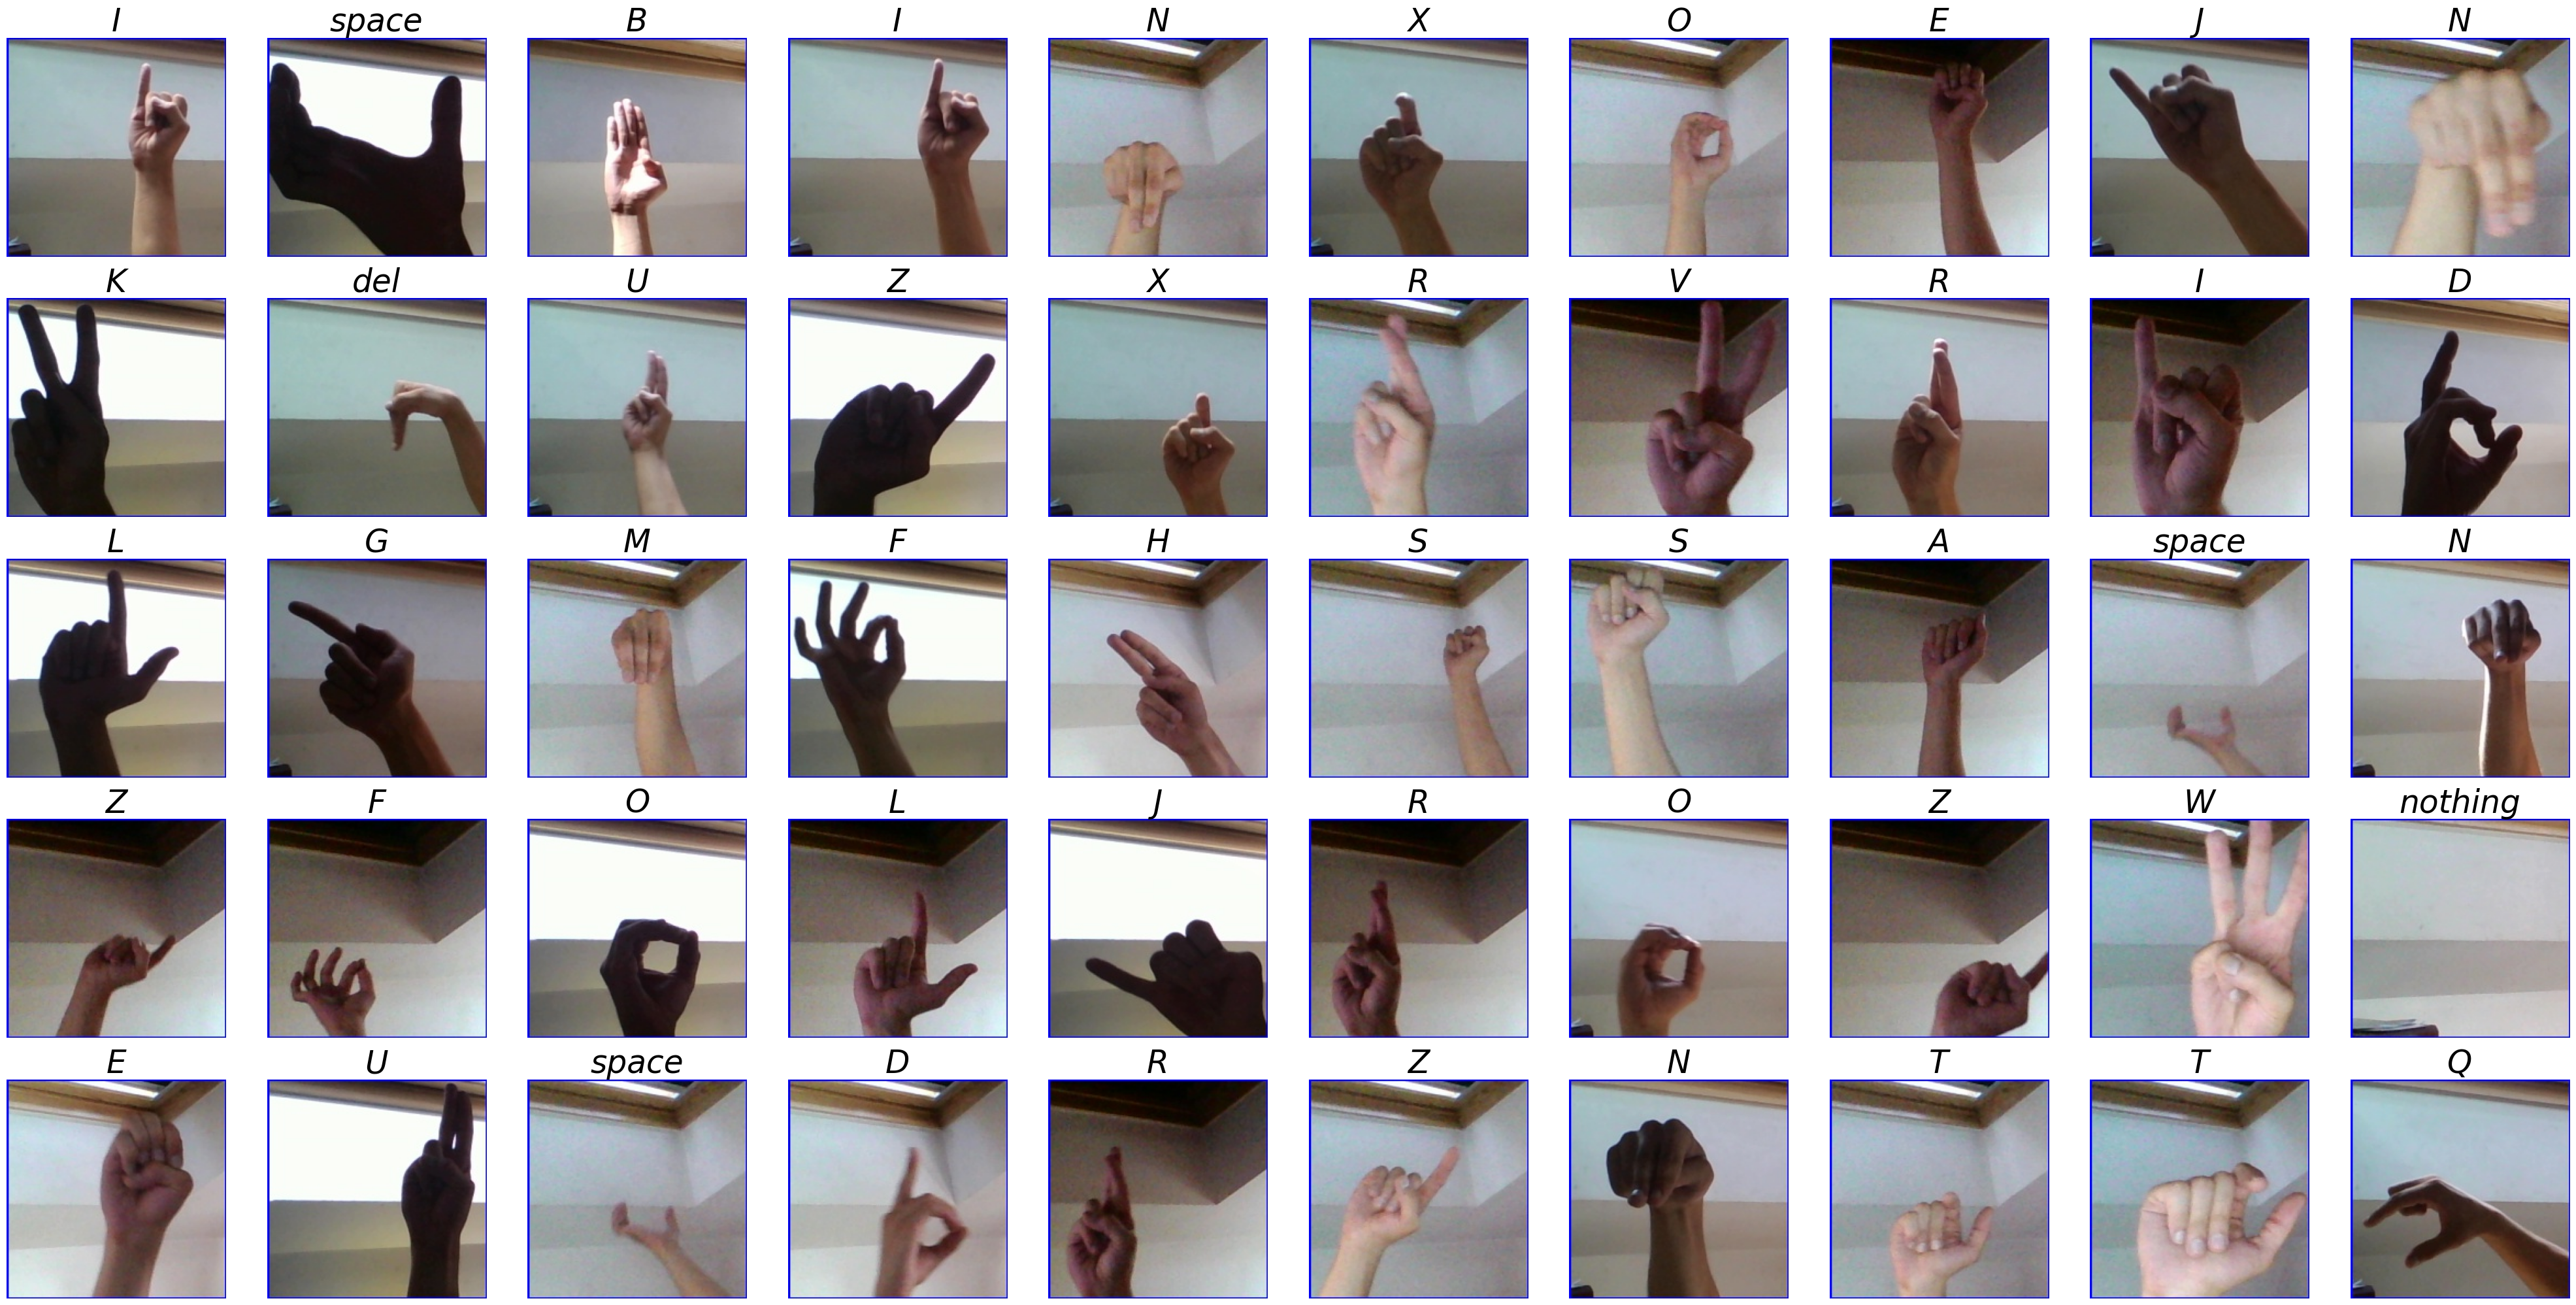

In [8]:
# Take 50 random images and viusalize them
sample_df = df.sample(50).reset_index(drop=True)

plt.figure(figsize=(40, 40))

for i in range(50):
    filepath = os.path.join(base_path, sample_df.filename.iloc[i])
    label = sample_df["category"].iloc[i]

    img = plt.imread(filepath)

    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=35, fontstyle='italic')
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8: Analyzing Class Distribution


/tmp/ipython-input-301072663.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uni, x='Category', y='Count', palette='icefire', width=0.4)


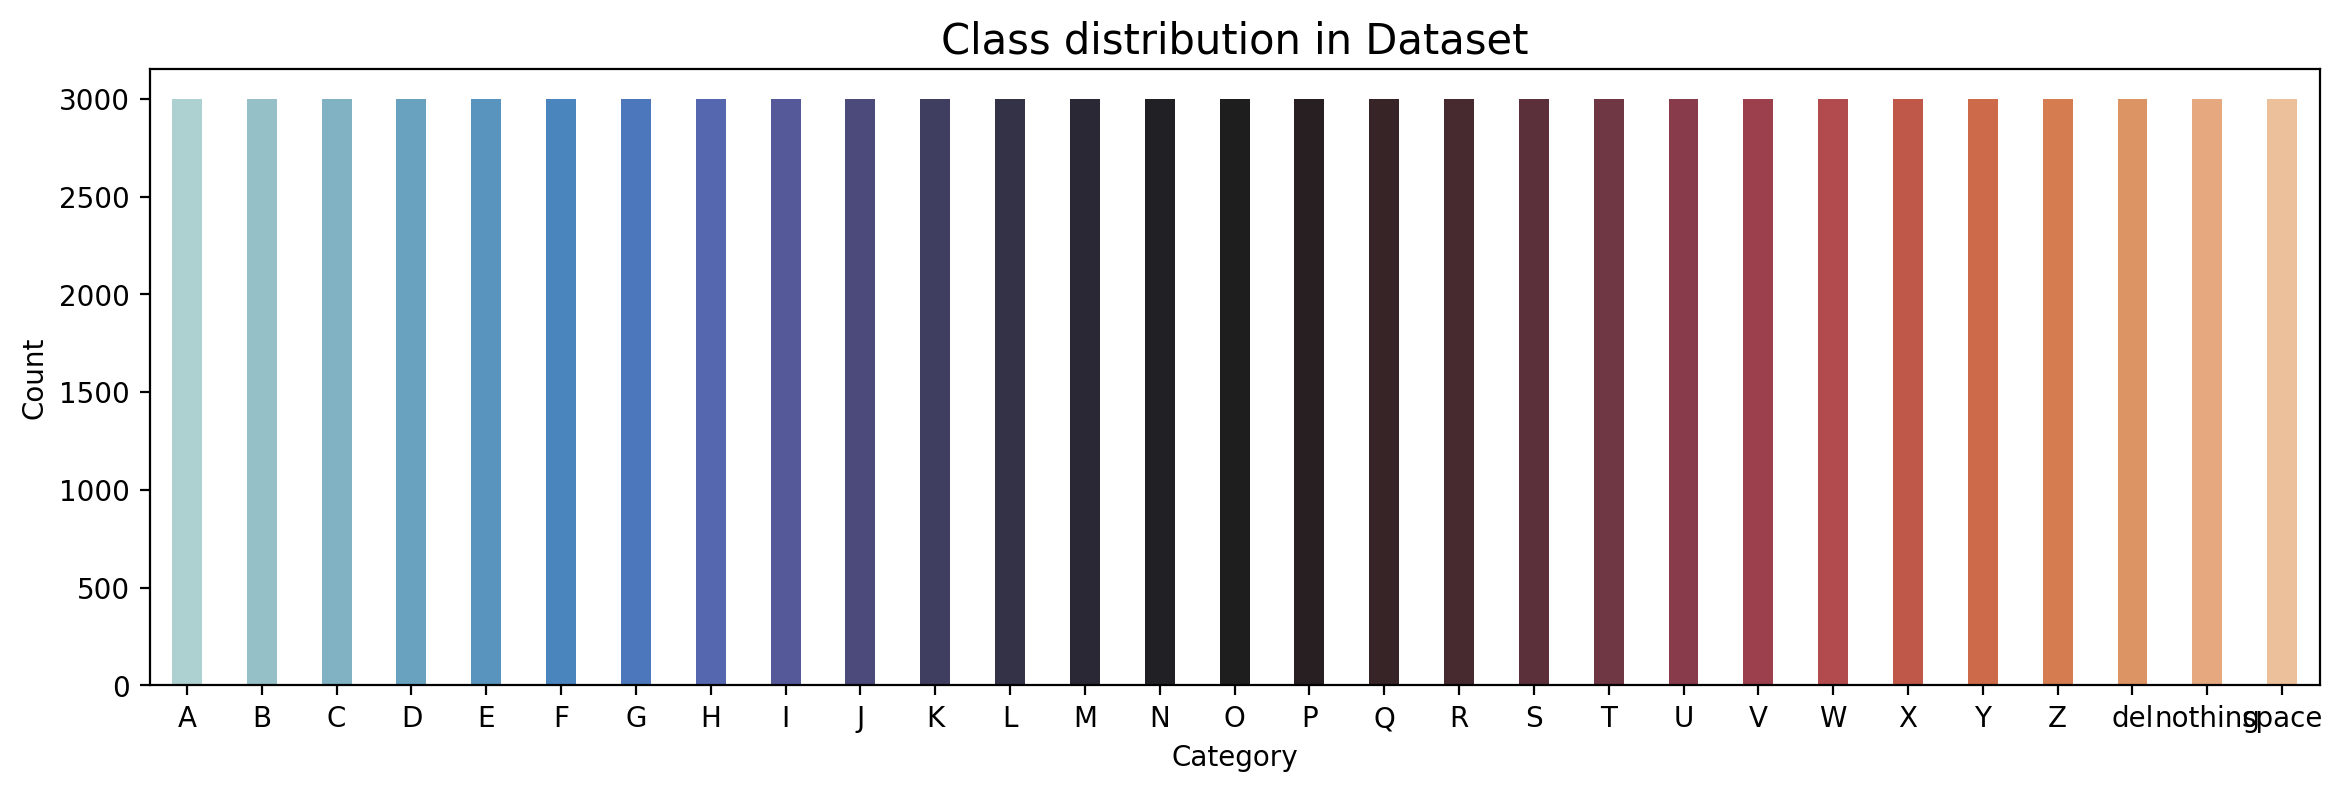

In [9]:
# Get count of all categories
category_counts = df['category'].value_counts().sort_index()

# Put into DataFrame to visualize better
uni = category_counts.reset_index()
uni.columns = ['Category', 'Count']

# Plot
plt.figure(figsize=(14,4), dpi=200)
sns.barplot(data=uni, x='Category', y='Count', palette='icefire', width=0.4)
plt.title('Class distribution in Dataset', fontsize=15)
plt.show()

All categories have equal count which is 3000

# 9: Split train data to train and validate




In [19]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)


Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


Make sure the split is correct

In [20]:
# Training class distribution
train_counts = np.bincount(train_generator.classes)
val_counts = np.bincount(validation_generator.classes)

print("Train class counts:", train_counts)
print("Validation class counts:", val_counts)

Train class counts: [2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400
 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400 2400
 2400]
Validation class counts: [600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600 600
 600 600 600 600 600 600 600 600 600 600 600]


# 10: Initialize the model

In [25]:
# To improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.05),
    layers.Lambda(lambda x: tf.image.random_brightness(x, max_delta=0.05)),
], name="data_augmentation")

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable = False
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = layers.Lambda(lambda t: preprocess_input(t * 255.0))(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(len(categories), activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint("best_model_stage1.h5", save_best_only=True, monitor="val_loss")
]

model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_14 (Lambda)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,205 (9.26 MB)

 Trainable params: 167,965 (656.11 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

#11: Fit model

In [26]:
asl_class = model.fit(train_generator,
                      validation_data= validation_generator,
                      epochs=10,
                      callbacks=callbacks,
                      verbose = 1)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7176 - loss: 1.0055

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 183s 81ms/step - accuracy: 0.7176 - loss: 1.0053 - val_accuracy: 0.8421 - val_loss: 0.5312 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8982 - loss: 0.3177

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 175s 81ms/step - accuracy: 0.8982 - loss: 0.3177 - val_accuracy: 0.8611 - val_loss: 0.4707 - learning_rate: 0.0010
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9121 - loss: 0.2741

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 174s 80ms/step - accuracy: 0.9121 - loss: 0.2741 - val_accuracy: 0.8656 - val_loss: 0.4665 - learning_rate: 0.0010
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 176s 81ms/step - accuracy: 0.9162 - loss: 0.2534 - val_accuracy: 0.8621 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 197s 78ms/step - accuracy: 0.9184 - loss: 0.2482 - val_accuracy: 0.8575 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 171s 79ms/step - accuracy: 0.9299 - loss: 0.2153 - val_accuracy: 0.8591 - val_loss: 0.4848 - learning_rate: 5.0000e-04
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9337 - loss: 0.2049

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 172s 79ms/step - accuracy: 0.9337 - loss: 0.2049 - val_accuracy: 0.8675 - val_loss: 0.4554 - learning_rate: 5.0000e-04
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9363 - loss: 0.1915

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 174s 80ms/step - accuracy: 0.9363 - loss: 0.1915 - val_accuracy: 0.8774 - val_loss: 0.4238 - learning_rate: 5.0000e-04
Epoch 9/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 170s 78ms/step - accuracy: 0.9411 - loss: 0.1817 - val_accuracy: 0.8569 - val_loss: 0.4931 - learning_rate: 5.0000e-04
Epoch 10/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 171s 79ms/step - accuracy: 0.9400 - loss: 0.1821 - val_accuracy: 0.8606 - val_loss: 0.4688 - learning_rate: 5.0000e-04


# 12: FineTune model

In [27]:
model.load_weights("best_model_stage1.h5")
# Unfreeze top layers of base_model
base_model.trainable = True
fine_tune_at = 120  # unfreeze last 120 layers (tune this)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower LR + label smoothing
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3)]
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_model_stage2.h5", save_best_only=True, monitor="val_loss")
]

# Fine-tune
history_ft = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7796 - loss: 1.4357 - top_k_categorical_accuracy: 0.9299

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 236s 103ms/step - accuracy: 0.7796 - loss: 1.4356 - top_k_categorical_accuracy: 0.9299 - val_accuracy: 0.8795 - val_loss: 1.1078 - val_top_k_categorical_accuracy: 0.9653 - learning_rate: 1.0000e-05
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9362 - loss: 0.9177 - top_k_categorical_accuracy: 0.9909

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 218s 100ms/step - accuracy: 0.9362 - loss: 0.9177 - top_k_categorical_accuracy: 0.9909 - val_accuracy: 0.8928 - val_loss: 0.9347 - val_top_k_categorical_accuracy: 0.9692 - learning_rate: 1.0000e-05
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9563 - loss: 0.8083 - top_k_categorical_accuracy: 0.9953

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 216s 99ms/step - accuracy: 0.9563 - loss: 0.8083 - top_k_categorical_accuracy: 0.9953 - val_accuracy: 0.8998 - val_loss: 0.8561 - val_top_k_categorical_accuracy: 0.9701 - learning_rate: 1.0000e-05
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9658 - loss: 0.7403 - top_k_categorical_accuracy: 0.9972

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 217s 100ms/step - accuracy: 0.9658 - loss: 0.7403 - top_k_categorical_accuracy: 0.9972 - val_accuracy: 0.9075 - val_loss: 0.7757 - val_top_k_categorical_accuracy: 0.9730 - learning_rate: 1.0000e-05
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9741 - loss: 0.6935 - top_k_categorical_accuracy: 0.9975

...

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 217s 100ms/step - accuracy: 0.9794 - loss: 0.6530 - top_k_categorical_accuracy: 0.9985 - val_accuracy: 0.9193 - val_loss: 0.7004 - val_top_k_categorical_accuracy: 0.9790 - learning_rate: 1.0000e-05
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9842 - loss: 0.6186 - top_k_categorical_accuracy: 0.9988

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 219s 100ms/step - accuracy: 0.9842 - loss: 0.6186 - top_k_categorical_accuracy: 0.9988 - val_accuracy: 0.9247 - val_loss: 0.6749 - val_top_k_categorical_accuracy: 0.9787 - learning_rate: 1.0000e-05
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9865 - loss: 0.5944 - top_k_categorical_accuracy: 0.9988

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 215s 99ms/step - accuracy: 0.9866 - loss: 0.5944 - top_k_categorical_accuracy: 0.9988 - val_accuracy: 0.9298 - val_loss: 0.6492 - val_top_k_categorical_accuracy: 0.9832 - learning_rate: 1.0000e-05
Epoch 9/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9890 - loss: 0.5726 - top_k_categorical_accuracy: 0.9992

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 217s 100ms/step - accuracy: 0.9890 - loss: 0.5726 - top_k_categorical_accuracy: 0.9992 - val_accuracy: 0.9385 - val_loss: 0.6220 - val_top_k_categorical_accuracy: 0.9854 - learning_rate: 1.0000e-05
Epoch 10/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9913 - loss: 0.5533 - top_k_categorical_accuracy: 0.9997

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 219s 100ms/step - accuracy: 0.9913 - loss: 0.5533 - top_k_categorical_accuracy: 0.9997 - val_accuracy: 0.9377 - val_loss: 0.6070 - val_top_k_categorical_accuracy: 0.9866 - learning_rate: 1.0000e-05


# 13: Evaluate model

In [40]:
test_path = os.path.join(dataset_path, 'asl_alphabet_test', 'asl_alphabet_test')
filepaths = []
labels = []
for fname in os.listdir(test_path):
    filepaths.append(os.path.join(test_path, fname))
    labels.append(fname.split("_")[0])  # "A_test.jpg" → "A"

test_df = pd.DataFrame({"filename": filepaths, "class": labels})

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=1,
    classes=list(train_generator.class_indices.keys())
)

model.load_weights("best_model_stage2.h5")
loss, acc, top3 = model.evaluate(test_generator, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc*100:.2f}%")

Found 28 validated image filenames belonging to 29 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test Loss: 0.4879
Test Accuracy: 100.00%


# 14. Testing with a Custom Image


Saving Screenshot 2025-09-25 232553.png to Screenshot 2025-09-25 232553 (1).png


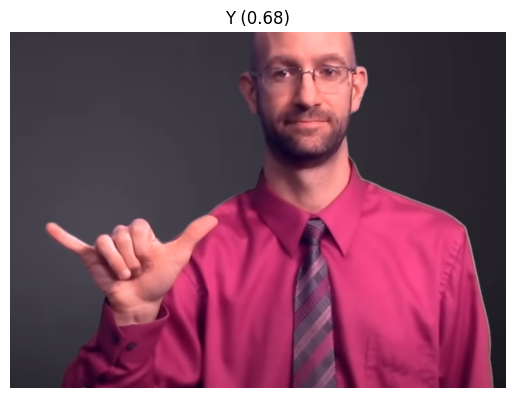

Prediction: Y, Confidence: 0.68


In [60]:
# Reverse mapping: index → class
index_to_class = {v: k for k, v in train_generator.class_indices.items()}

def predict_image(model, img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    # Load & preprocess
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    # Predict
    preds = model.predict(x, verbose=0)[0]
    idx = np.argmax(preds)
    return index_to_class[idx], preds[idx]

uploaded = files.upload()
for fn in uploaded.keys():
    pred_class, conf = predict_image(model, fn)
    plt.imshow(image.load_img(fn))
    plt.title(f"{pred_class} ({conf:.2f})")
    plt.axis("off")
    plt.show()
    print(f"Prediction: {pred_class}, Confidence: {conf:.2f}")
